# AP M2 - EfficientNetV2-S sem leakage + threshold tuning



In [36]:
# =========================
# 1. Imports e configuração
# =========================

import os
import gc
import json
import random
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation


In [37]:
# =========================
# 2. Configuração principal
# =========================

DATA_ROOT = Path('/mounts/mecd-ap-g5/data')
DATASET_DIR = DATA_ROOT / 'MIQR-CC-Dataset'
PROCESSED_IMAGES_DIR = DATASET_DIR / 'processed'
METADATA_PATH = DATASET_DIR / 'metadata.csv'

NOTEBOOK_NAME = 'efficientnetv2s_no_leakage_threshold_tuning'
RESULTS_DIR = Path('/mounts/mecd-ap-g5/results') / NOTEBOOK_NAME
MODELS_DIR = Path('/mounts/mecd-ap-g5/models') / NOTEBOOK_NAME
FIGURES_DIR = RESULTS_DIR / 'figures'
CSV_DIR = RESULTS_DIR / 'csv'

for d in [RESULTS_DIR, MODELS_DIR, FIGURES_DIR, CSV_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Se der CUDA out of memory:
# IMG_SIZE = 192
# BATCH_SIZE = 2
# ACCUMULATION_STEPS = 8
# NUM_WORKERS = 0
# PIN_MEMORY = False

IMG_SIZE = 224
BATCH_SIZE = 4
ACCUMULATION_STEPS = 4
NUM_WORKERS = 0
PIN_MEMORY = False

EPOCHS_HEAD = 8
EPOCHS_FINETUNE = 20
PATIENCE = 6

LR_HEAD = 3e-4
LR_BACKBONE = 1e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05

BASELINE_MACRO_F1 = 0.738
NUM_CLASSES = 4

print('Metadata:', METADATA_PATH)
print('Images:', PROCESSED_IMAGES_DIR)
print('Results:', RESULTS_DIR)
print('Models:', MODELS_DIR)

Metadata: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset/metadata.csv
Images: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset/processed
Results: /mounts/mecd-ap-g5/results/efficientnetv2s_no_leakage_threshold_tuning
Models: /mounts/mecd-ap-g5/models/efficientnetv2s_no_leakage_threshold_tuning


In [38]:
# =========================
# 4. Carregar metadata
# =========================

assert METADATA_PATH.exists(), f"METADATA_PATH não existe: {METADATA_PATH}"
assert PROCESSED_IMAGES_DIR.exists(), f"PROCESSED_IMAGES_DIR não existe: {PROCESSED_IMAGES_DIR}"

df = pd.read_csv(METADATA_PATH)
print("Shape original:", df.shape)
display(df.head())
print("Colunas:", df.columns.tolist())

required_cols = ["processed_image_path", "patient_id", "Label", "Keep"]
for col in required_cols:
    assert col in df.columns, f"Coluna obrigatória ausente: {col}"

df = df[df["Keep"].astype(str).str.lower() == "keep"].copy()
df = df[~df["Label"].astype(str).str.lower().isin(["unlabelled", "unlabeled", "nan", "none", ""])].copy()

print("Shape após Keep + remoção Unlabelled:", df.shape)
display(df["Label"].value_counts())

Shape original: (19317, 12)


,raw_image_path,processed_image_path,patient_id,image_type,sex,birth_date,exam_date,exam_time,age,equipment_model,Label,Keep
0,raw/1_image1.png,processed/1_image1.png,1,S,M,22/08/1952,03/02/2022,11:50:32,69.0,Ziehm Vision RFD,Unlabelled,Keep
1,raw/1_image2.png,processed/1_image2.png,1,S,M,22/08/1952,03/02/2022,11:47:43,69.0,Ziehm Vision RFD,Unlabelled,Keep
2,raw/1_image3.png,processed/1_image3.png,1,S,M,22/08/1952,03/02/2022,12:08:45,69.0,Ziehm Vision RFD,Unlabelled,Keep
3,raw/1_image4.png,processed/1_image4.png,1,S,M,22/08/1952,03/02/2022,11:50:22,69.0,Ziehm Vision RFD,Unlabelled,Keep
4,raw/2_image5.png,processed/2_image5.png,2,S,F,15/08/1925,21/06/2022,20:09:00,96.0,Ziehm Vision RFD,Lithiasis,Discard


Colunas: ['raw_image_path', 'processed_image_path', 'patient_id', 'image_type', 'sex', 'birth_date', 'exam_date', 'exam_time', 'age', 'equipment_model', 'Label', 'Keep']
Shape após Keep + remoção Unlabelled: (1568, 12)


Label
Lithiasis              726
Malignant Stricture    329
Normal                 299
Biliary Leaks          151
Benign Stricture        63
Name: count, dtype: int64

In [39]:
# =========================
# 5. Mapear para 4 classes principais
# =========================

def map_to_4_classes(label):
    label = str(label).strip()
    if label in ["Benign Stricture", "Malignant Stricture", "Stricture"]:
        return "Stricture"
    elif label in ["Biliary Leaks", "Biliary_Leaks", "Bile Leaks"]:
        return "Biliary Leaks"
    elif label in ["Lithiasis", "Stones", "Biliary lithiasis"]:
        return "Lithiasis"
    elif label == "Normal":
        return "Normal"
    else:
        return None

df["label"] = df["Label"].apply(map_to_4_classes)
df = df[df["label"].notna()].copy()

class_names = ["Biliary Leaks", "Lithiasis", "Stricture", "Normal"]
class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

df["label_idx"] = df["label"].map(class_to_idx).astype(int)
df["patient_id"] = df["patient_id"].astype(str)

print("Distribuição final das 4 classes:")
display(df["label"].value_counts().reindex(class_names))
print("Total:", len(df))
print("Pacientes:", df["patient_id"].nunique())

Distribuição final das 4 classes:


label
Biliary Leaks    151
Lithiasis        726
Stricture        392
Normal           299
Name: count, dtype: int64

Total: 1568
Pacientes: 436


In [40]:
# =========================
# 6. Resolver caminhos das imagens
# =========================

def resolve_processed_path(x):
    x = str(x)
    p = Path(x)
    if p.exists():
        return p
    p2 = DATASET_DIR / x
    if p2.exists():
        return p2
    p3 = PROCESSED_IMAGES_DIR / p.name
    if p3.exists():
        return p3
    return None

df["image_path"] = df["processed_image_path"].apply(resolve_processed_path)

missing = df["image_path"].isna().sum()
print(f"Imagens não encontradas: {missing} / {len(df)}")
if missing > 0:
    display(df[df["image_path"].isna()].head())

df = df[df["image_path"].notna()].copy()
df["image_path"] = df["image_path"].astype(str)

print("Shape final com imagens existentes:", df.shape)
display(df[["image_path", "label", "patient_id"]].head())

Imagens não encontradas: 0 / 1568
Shape final com imagens existentes: (1568, 15)


,image_path,label,patient_id
23,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Normal,3
36,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,5
50,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Normal,6
65,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,9
68,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,9


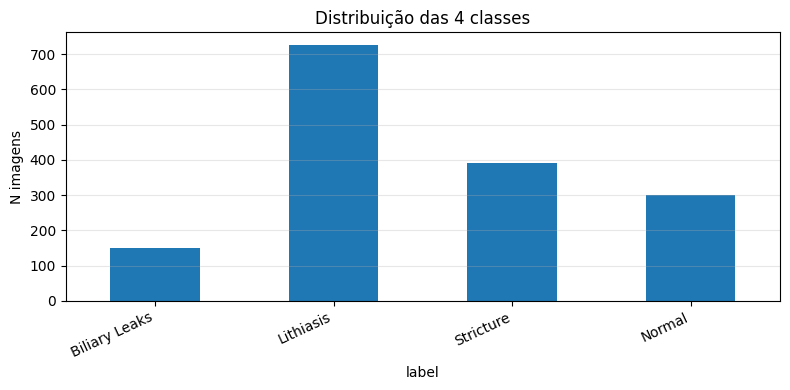

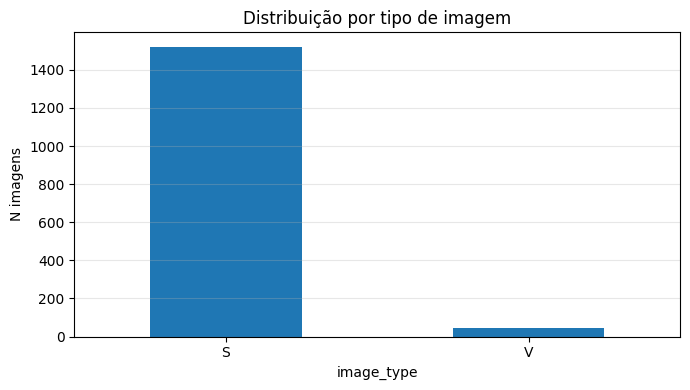

image_type,S,V
label,,
Biliary Leaks,146,5
Lithiasis,712,14
Normal,276,23
Stricture,387,5


In [41]:
# =========================
# 7. EDA
# =========================

plt.figure(figsize=(8, 4))
df["label"].value_counts().reindex(class_names).plot(kind="bar")
plt.title("Distribuição das 4 classes")
plt.ylabel("N imagens")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

if "image_type" in df.columns:
    plt.figure(figsize=(7, 4))
    df["image_type"].value_counts().plot(kind="bar")
    plt.title("Distribuição por tipo de imagem")
    plt.ylabel("N imagens")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "eda_image_type_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()
    display(pd.crosstab(df["label"], df["image_type"]))

df.to_csv(CSV_DIR / "dataset_4class_filtered.csv", index=False)

In [42]:
# =========================
# 8. Split sem leakage: StratifiedGroupKFold
# =========================

df = df.reset_index(drop=True).copy()
X = df["image_path"].values
y = df["label_idx"].values
groups = df["patient_id"].values

def distribution_score(train_idx, temp_idx, data):
    classes = list(range(NUM_CLASSES))
    full_dist = data["label_idx"].value_counts(normalize=True).sort_index().reindex(classes, fill_value=0)
    train_dist = data.iloc[train_idx]["label_idx"].value_counts(normalize=True).sort_index().reindex(classes, fill_value=0)
    temp_dist = data.iloc[temp_idx]["label_idx"].value_counts(normalize=True).sort_index().reindex(classes, fill_value=0)
    score = np.abs(train_dist - full_dist).sum() + np.abs(temp_dist - full_dist).sum()
    score += 10 * (temp_dist == 0).sum()
    return score

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
splits = list(sgkf.split(X, y, groups))

train_idx, temp_idx = min(
    splits,
    key=lambda split: distribution_score(split[0], split[1], df)
)

train_df = df.iloc[train_idx].copy()
temp_df = df.iloc[temp_idx].copy()

X_temp = temp_df["image_path"].values
y_temp = temp_df["label_idx"].values
groups_temp = temp_df["patient_id"].values

sgkf_temp = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=SEED)
temp_splits = list(sgkf_temp.split(X_temp, y_temp, groups_temp))

val_idx, test_idx = min(
    temp_splits,
    key=lambda split: distribution_score(split[0], split[1], temp_df)
)

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

print("Split mode: StratifiedGroupKFold por patient_id")

for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print("\\n", name.upper(), "images:", len(split_df), "patients:", split_df["patient_id"].nunique())
    print(split_df["label"].value_counts().reindex(class_names, fill_value=0))

train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])
test_patients = set(test_df["patient_id"])

leak_train_val = len(train_patients & val_patients)
leak_train_test = len(train_patients & test_patients)
leak_val_test = len(val_patients & test_patients)

print("\\nVerificação de leakage por patient_id:")
print("Interseção treino-val:", leak_train_val)
print("Interseção treino-teste:", leak_train_test)
print("Interseção val-teste:", leak_val_test)

assert leak_train_val == 0
assert leak_train_test == 0
assert leak_val_test == 0

split_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "n_images": [len(train_df), len(val_df), len(test_df)],
    "n_patients": [train_df["patient_id"].nunique(), val_df["patient_id"].nunique(), test_df["patient_id"].nunique()]
})
display(split_summary)

train_df.to_csv(CSV_DIR / "train_split.csv", index=False)
val_df.to_csv(CSV_DIR / "val_split.csv", index=False)
test_df.to_csv(CSV_DIR / "test_split.csv", index=False)
split_summary.to_csv(CSV_DIR / "split_summary_no_leakage.csv", index=False)

Split mode: StratifiedGroupKFold por patient_id
\n TRAIN images: 1266 patients: 346
label
Biliary Leaks    133
Lithiasis        590
Stricture        301
Normal           242
Name: count, dtype: int64
\n VAL images: 144 patients: 45
label
Biliary Leaks     2
Lithiasis        73
Stricture        40
Normal           29
Name: count, dtype: int64
\n TEST images: 158 patients: 45
label
Biliary Leaks    16
Lithiasis        63
Stricture        51
Normal           28
Name: count, dtype: int64
\nVerificação de leakage por patient_id:
Interseção treino-val: 0
Interseção treino-teste: 0
Interseção val-teste: 0


,split,n_images,n_patients
0,train,1266,346
1,val,144,45
2,test,158,45


In [43]:
# =========================
# 9. Dataset e transformações
# =========================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class ERCPDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = int(row["label_idx"])
        return img, label

train_dataset = ERCPDataset(train_df, transform=train_transform)
val_dataset = ERCPDataset(val_df, transform=eval_transform)
test_dataset = ERCPDataset(test_df, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 317
Val batches: 36
Test batches: 40


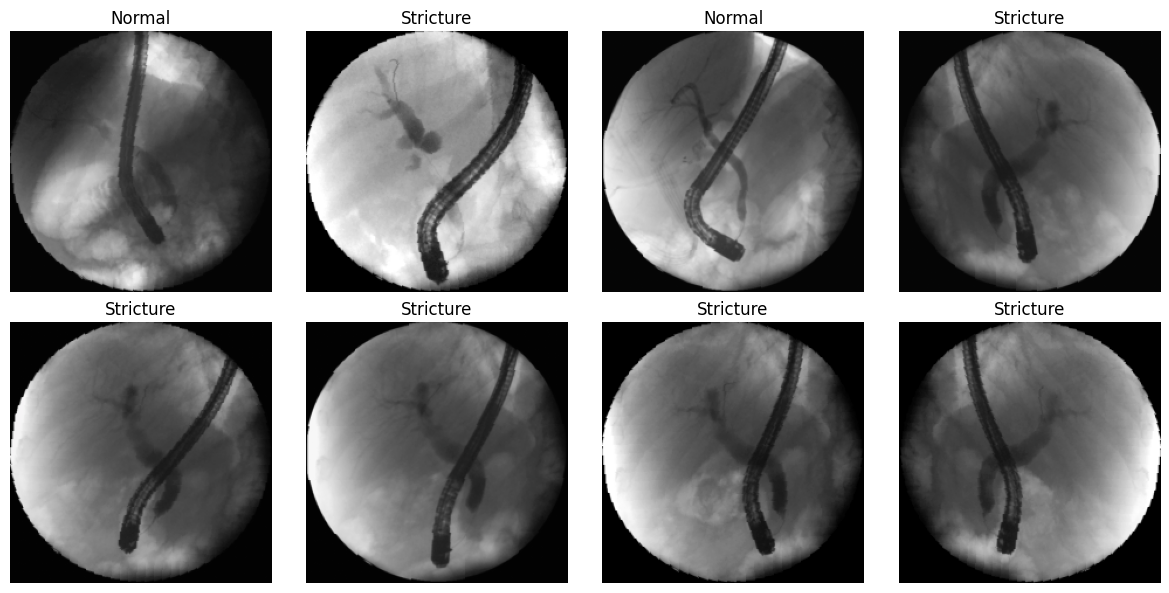

In [44]:
# =========================
# 10. Visualizar amostras
# =========================

def denormalize_tensor(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    x = t.cpu() * std + mean
    return x.clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

for i in range(min(8, len(train_dataset))):
    img, label = train_dataset[i]
    img_show = denormalize_tensor(img).permute(1, 2, 0).numpy()
    axes[i].imshow(img_show)
    axes[i].set_title(class_names[label])
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "train_samples.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
# =========================
# 11. Loss: CrossEntropy ponderada com label smoothing
# =========================

class_counts = train_df["label_idx"].value_counts().sort_index().reindex(range(NUM_CLASSES), fill_value=0)

class_weights_np = len(train_df) / (NUM_CLASSES * class_counts.replace(0, np.nan))
class_weights_np = class_weights_np.fillna(0).values.astype(np.float32)

# suavização de pesos extremos
class_weights_np = np.sqrt(class_weights_np)
class_weights_np = class_weights_np / class_weights_np.mean()

class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

print("Class counts:", class_counts.to_dict())
print("Class weights:", class_weights_np)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING
)

Class counts: {0: 133, 1: 590, 2: 301, 3: 242}
Class weights: [1.3884766  0.65923214 0.92295635 1.0293349 ]


In [46]:
# =========================
# 12. Criar modelo EfficientNetV2-S
# =========================

def create_model(num_classes=4):
    weights = models.EfficientNet_V2_S_Weights.IMAGENET1K_V1
    model = models.efficientnet_v2_s(weights=weights)
    in_features = model.classifier[-1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.35),
        nn.Linear(in_features, num_classes)
    )
    return model

model = create_model(NUM_CLASSES).to(device)
print(model.classifier)

def set_backbone_trainable(model, trainable=False):
    for param in model.features.parameters():
        param.requires_grad = trainable

def set_last_blocks_trainable(model, n_blocks=3):
    for param in model.features.parameters():
        param.requires_grad = False
    for block in model.features[-n_blocks:]:
        for param in block.parameters():
            param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True

set_backbone_trainable(model, trainable=False)
for param in model.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Parâmetros treináveis: {trainable:,} / {total:,}")

Sequential(
  (0): Dropout(p=0.35, inplace=False)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)
Parâmetros treináveis: 5,124 / 20,182,612


In [47]:
# =========================
# 13. Funções de treino e avaliação
# =========================

try:
    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
except TypeError:
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

def compute_metrics(y_true, y_pred, y_prob=None):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }
    if y_prob is not None:
        y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
        try:
            metrics["roc_auc_macro_ovr"] = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
        except Exception:
            metrics["roc_auc_macro_ovr"] = np.nan
        try:
            metrics["pr_auc_macro"] = average_precision_score(y_true_bin, y_prob, average="macro")
        except Exception:
            metrics["pr_auc_macro"] = np.nan
    return metrics

def evaluate(model, loader):
    model.eval()
    all_true, all_pred, all_prob = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)

            all_true.extend(labels.cpu().numpy())
            all_pred.extend(preds.cpu().numpy())
            all_prob.extend(probs.cpu().numpy())

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)
    all_prob = np.array(all_prob)

    metrics = compute_metrics(all_true, all_pred, all_prob)
    metrics["y_true"] = all_true
    metrics["y_pred"] = all_pred
    metrics["y_prob"] = all_prob
    return metrics

def train_one_epoch(model, loader, optimizer, criterion, accumulation_steps=1):
    model.train()
    running_loss = 0.0
    n_samples = 0

    optimizer.zero_grad(set_to_none=True)

    for step, (images, labels) in enumerate(loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        try:
            autocast_ctx = torch.amp.autocast("cuda", enabled=torch.cuda.is_available())
        except TypeError:
            autocast_ctx = torch.cuda.amp.autocast(enabled=torch.cuda.is_available())

        with autocast_ctx:
            logits = model(images)
            loss = criterion(logits, labels)
            loss_for_backward = loss / accumulation_steps

        scaler.scale(loss_for_backward).backward()

        if (step + 1) % accumulation_steps == 0 or (step + 1) == len(loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size

    return running_loss / max(1, n_samples)

def run_training_phase(model, phase_name, epochs, optimizer, scheduler=None):
    history = []
    best_val_f1 = -1
    best_path = MODELS_DIR / f"best_{phase_name}.pt"
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, ACCUMULATION_STEPS)
        val_metrics = evaluate(model, val_loader)

        row = {
            "phase": phase_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_accuracy": val_metrics["accuracy"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_weighted_f1": val_metrics["weighted_f1"],
            "val_macro_precision": val_metrics["macro_precision"],
            "val_macro_recall": val_metrics["macro_recall"],
            "val_roc_auc_macro_ovr": val_metrics.get("roc_auc_macro_ovr", np.nan),
            "val_pr_auc_macro": val_metrics.get("pr_auc_macro", np.nan),
        }
        history.append(row)

        if scheduler is not None:
            scheduler.step(val_metrics["macro_f1"])

        print(
            f"[{phase_name}] Epoch {epoch:02d}/{epochs} | "
            f"loss={train_loss:.4f} | "
            f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
            f"val_bal_acc={val_metrics['balanced_accuracy']:.4f} | "
            f"val_auc={val_metrics.get('roc_auc_macro_ovr', np.nan):.4f}"
        )

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            patience_counter = 0
            torch.save(model.state_dict(), best_path)
            print("  -> novo melhor modelo guardado:", best_path)
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"Early stopping em {phase_name}.")
            break

    return history, best_path, best_val_f1

In [48]:
# =========================
# 14. Fase 1 — treinar cabeça
# =========================

optimizer_head = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY
)

scheduler_head = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_head,
    mode="max",
    factor=0.5,
    patience=2
)

hist_head, best_head_path, best_head_f1 = run_training_phase(
    model,
    phase_name="head",
    epochs=EPOCHS_HEAD,
    optimizer=optimizer_head,
    scheduler=scheduler_head
)

print("Melhor F1 validação fase head:", best_head_f1)

[head] Epoch 01/8 | loss=1.3782 | val_macro_f1=0.2642 | val_bal_acc=0.2583 | val_auc=0.5583
  -> novo melhor modelo guardado: /mounts/mecd-ap-g5/models/efficientnetv2s_no_leakage_threshold_tuning/best_head.pt
[head] Epoch 02/8 | loss=1.3457 | val_macro_f1=0.2343 | val_bal_acc=0.2164 | val_auc=0.5819
[head] Epoch 03/8 | loss=1.3276 | val_macro_f1=0.2296 | val_bal_acc=0.2165 | val_auc=0.6020
[head] Epoch 04/8 | loss=1.3068 | val_macro_f1=0.2065 | val_bal_acc=0.1929 | val_auc=0.5426
[head] Epoch 05/8 | loss=1.2995 | val_macro_f1=0.1831 | val_bal_acc=0.1667 | val_auc=0.5377
[head] Epoch 06/8 | loss=1.3062 | val_macro_f1=0.2100 | val_bal_acc=0.1969 | val_auc=0.5704
[head] Epoch 07/8 | loss=1.2956 | val_macro_f1=0.2064 | val_bal_acc=0.1884 | val_auc=0.5911
Early stopping em head.
Melhor F1 validação fase head: 0.26419682259488086


In [49]:
# =========================
# 15. Fase 2 — fine-tuning parcial
# =========================

model.load_state_dict(torch.load(best_head_path, map_location=device))

set_last_blocks_trainable(model, n_blocks=3)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Parâmetros treináveis após fine-tuning parcial: {trainable:,} / {total:,}")

optimizer_ft = torch.optim.AdamW([
    {"params": model.features[-3:].parameters(), "lr": LR_BACKBONE},
    {"params": model.classifier.parameters(), "lr": LR_HEAD * 0.5},
], weight_decay=WEIGHT_DECAY)

scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode="max",
    factor=0.5,
    patience=2
)

hist_ft, best_ft_path, best_ft_f1 = run_training_phase(
    model,
    phase_name="finetune",
    epochs=EPOCHS_FINETUNE,
    optimizer=optimizer_ft,
    scheduler=scheduler_ft
)

print("Melhor F1 validação fine-tuning:", best_ft_f1)

Parâmetros treináveis após fine-tuning parcial: 18,361,036 / 20,182,612
[finetune] Epoch 01/20 | loss=1.3352 | val_macro_f1=0.2987 | val_bal_acc=0.2906 | val_auc=0.5591
  -> novo melhor modelo guardado: /mounts/mecd-ap-g5/models/efficientnetv2s_no_leakage_threshold_tuning/best_finetune.pt
[finetune] Epoch 02/20 | loss=1.3089 | val_macro_f1=0.2817 | val_bal_acc=0.2798 | val_auc=0.5956
[finetune] Epoch 03/20 | loss=1.2843 | val_macro_f1=0.2416 | val_bal_acc=0.2301 | val_auc=0.6098
[finetune] Epoch 04/20 | loss=1.2431 | val_macro_f1=0.2257 | val_bal_acc=0.3275 | val_auc=0.6234
[finetune] Epoch 05/20 | loss=1.1959 | val_macro_f1=0.2007 | val_bal_acc=0.2115 | val_auc=0.6167
[finetune] Epoch 06/20 | loss=1.1957 | val_macro_f1=0.2381 | val_bal_acc=0.3389 | val_auc=0.6278
[finetune] Epoch 07/20 | loss=1.1725 | val_macro_f1=0.1810 | val_bal_acc=0.1876 | val_auc=0.6227
Early stopping em finetune.
Melhor F1 validação fine-tuning: 0.2986573402486603


In [50]:
# =========================
# 16. Escolher melhor modelo global
# =========================

if best_ft_f1 >= best_head_f1:
    best_model_path = best_ft_path
    best_phase = "finetune"
    best_val_f1 = best_ft_f1
else:
    best_model_path = best_head_path
    best_phase = "head"
    best_val_f1 = best_head_f1

model.load_state_dict(torch.load(best_model_path, map_location=device))
model = model.to(device)

print("Melhor fase:", best_phase)
print("Melhor Val Macro F1:", best_val_f1)
print("Modelo:", best_model_path)

torch.save(model.state_dict(), MODELS_DIR / "best_model_global.pt")

Melhor fase: finetune
Melhor Val Macro F1: 0.2986573402486603
Modelo: /mounts/mecd-ap-g5/models/efficientnetv2s_no_leakage_threshold_tuning/best_finetune.pt


,phase,epoch,train_loss,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,val_macro_precision,val_macro_recall,val_roc_auc_macro_ovr,val_pr_auc_macro,global_epoch
9,finetune,3,1.284276,0.340278,0.230063,0.241599,0.354796,0.265234,0.230063,0.609848,0.300724,10
10,finetune,4,1.243095,0.388889,0.327483,0.225678,0.335239,0.194444,0.327483,0.623370,0.321228,11
11,finetune,5,1.195935,0.361111,0.211532,0.200653,0.332603,0.294456,0.211532,0.616666,0.313136,12
12,finetune,6,1.195687,0.395833,0.338929,0.238052,0.355449,0.235876,0.338929,0.627793,0.326752,13
13,finetune,7,1.172542,0.312500,0.187559,0.181038,0.297447,0.192564,0.187559,0.622750,0.305531,14


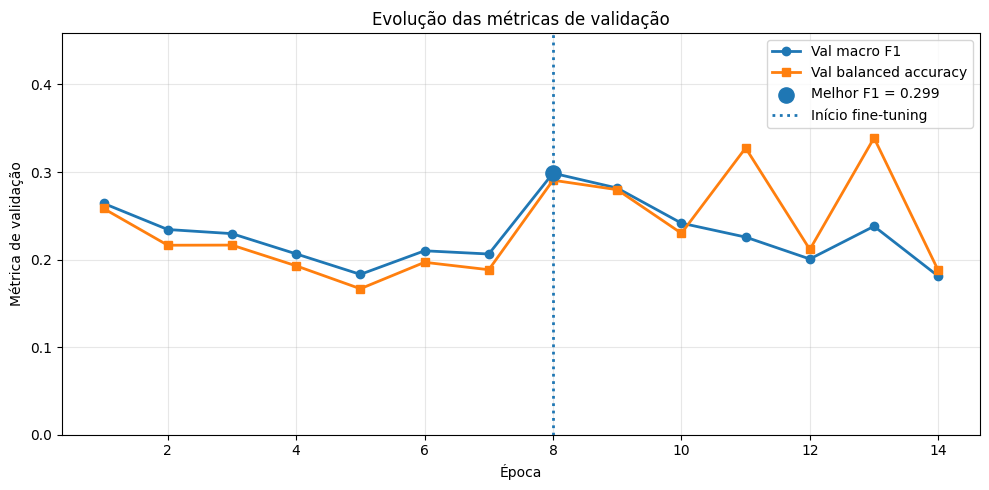

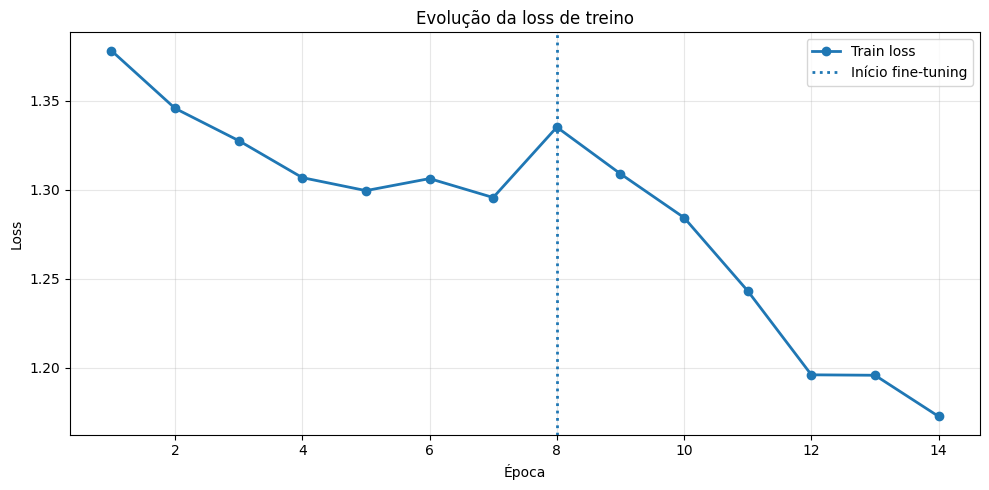

In [51]:
# =========================
# 17. Curvas de treino
# =========================

hist_df = pd.concat([pd.DataFrame(hist_head), pd.DataFrame(hist_ft)], ignore_index=True)
hist_df["global_epoch"] = np.arange(1, len(hist_df) + 1)
hist_df.to_csv(CSV_DIR / "training_history.csv", index=False)
display(hist_df.tail())

phase_change_epoch = None
if hist_df["phase"].nunique() > 1:
    first_phase = hist_df["phase"].iloc[0]
    change_rows = hist_df[hist_df["phase"] != first_phase]
    if len(change_rows) > 0:
        phase_change_epoch = int(change_rows["global_epoch"].iloc[0])

best_idx = hist_df["val_macro_f1"].idxmax()
best_epoch = int(hist_df.loc[best_idx, "global_epoch"])
best_f1 = float(hist_df.loc[best_idx, "val_macro_f1"])

plt.figure(figsize=(10, 5))
plt.plot(hist_df["global_epoch"], hist_df["val_macro_f1"], marker="o", linewidth=2, label="Val macro F1")
plt.plot(hist_df["global_epoch"], hist_df["val_balanced_accuracy"], marker="s", linewidth=2, label="Val balanced accuracy")
plt.scatter(best_epoch, best_f1, s=120, zorder=5, label=f"Melhor F1 = {best_f1:.3f}")
if phase_change_epoch is not None:
    plt.axvline(phase_change_epoch, linestyle=":", linewidth=2, label="Início fine-tuning")
plt.xlabel("Época")
plt.ylabel("Métrica de validação")
plt.title("Evolução das métricas de validação")
plt.ylim(0, min(1.0, max(hist_df["val_macro_f1"].max(), hist_df["val_balanced_accuracy"].max()) + 0.12))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "training_metrics_zoomed.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(hist_df["global_epoch"], hist_df["train_loss"], marker="o", linewidth=2, label="Train loss")
if phase_change_epoch is not None:
    plt.axvline(phase_change_epoch, linestyle=":", linewidth=2, label="Início fine-tuning")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Evolução da loss de treino")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "training_loss.png", dpi=300, bbox_inches="tight")
plt.show()

In [52]:
# =========================
# 18. Threshold tuning na validação
# =========================

def predict_with_thresholds(probs, thresholds):
    thresholds = np.asarray(thresholds, dtype=np.float32)
    adjusted = probs / thresholds
    return adjusted.argmax(axis=1)

def find_best_thresholds(y_true, y_prob, num_classes=4):
    grid = [0.35, 0.50, 0.65, 0.80, 1.00, 1.20, 1.40, 1.60]
    best_f1 = -1
    best_thresholds = None

    for thresholds in product(grid, repeat=num_classes):
        thresholds = np.array(thresholds, dtype=np.float32)
        y_pred = predict_with_thresholds(y_prob, thresholds)
        f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_thresholds = thresholds

    return best_thresholds, best_f1

val_metrics = evaluate(model, val_loader)

best_thresholds, best_val_f1_thr = find_best_thresholds(
    val_metrics["y_true"],
    val_metrics["y_prob"],
    num_classes=NUM_CLASSES
)

print("Macro F1 validação original:", val_metrics["macro_f1"])
print("Melhores thresholds:", best_thresholds)
print("Macro F1 validação com thresholds:", best_val_f1_thr)

thresholds_df = pd.DataFrame({"class": class_names, "threshold": best_thresholds})
display(thresholds_df)
thresholds_df.to_csv(CSV_DIR / "best_thresholds_validation.csv", index=False)

Macro F1 validação original: 0.2986573402486603
Melhores thresholds: [1.6 1.2 1.2 1.4]
Macro F1 validação com thresholds: 0.304029304029304


,class,threshold
0,Biliary Leaks,1.6
1,Lithiasis,1.2
2,Stricture,1.2
3,Normal,1.4


In [53]:
# =========================
# 19. Test-Time Augmentation
# =========================

def tta_predict_one(model, image_tensor):
    model.eval()
    variants = [
        image_tensor,
        torch.flip(image_tensor, dims=[2]),  # horizontal flip
    ]

    probs_all = []

    with torch.no_grad():
        for img in variants:
            x = img.unsqueeze(0).to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)
            probs_all.append(probs.cpu())

    probs_mean = torch.mean(torch.stack(probs_all), dim=0)
    return probs_mean.squeeze(0).numpy()

def evaluate_tta(model, dataset):
    y_true = []
    y_prob = []

    for i in range(len(dataset)):
        img, label = dataset[i]
        probs = tta_predict_one(model, img)
        y_true.append(label)
        y_prob.append(probs)

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = y_prob.argmax(axis=1)

    metrics = compute_metrics(y_true, y_pred, y_prob)
    metrics["y_true"] = y_true
    metrics["y_pred"] = y_pred
    metrics["y_prob"] = y_prob
    return metrics

In [54]:
# =========================
# 20. Avaliação no teste
# =========================

test_metrics = evaluate(model, test_loader)

y_pred_thr = predict_with_thresholds(test_metrics["y_prob"], best_thresholds)
test_metrics_thr = compute_metrics(test_metrics["y_true"], y_pred_thr, test_metrics["y_prob"])
test_metrics_thr["y_true"] = test_metrics["y_true"]
test_metrics_thr["y_pred"] = y_pred_thr
test_metrics_thr["y_prob"] = test_metrics["y_prob"]

test_tta_metrics = evaluate_tta(model, test_dataset)

y_pred_tta_thr = predict_with_thresholds(test_tta_metrics["y_prob"], best_thresholds)
test_tta_thr_metrics = compute_metrics(test_tta_metrics["y_true"], y_pred_tta_thr, test_tta_metrics["y_prob"])
test_tta_thr_metrics["y_true"] = test_tta_metrics["y_true"]
test_tta_thr_metrics["y_pred"] = y_pred_tta_thr
test_tta_thr_metrics["y_prob"] = test_tta_metrics["y_prob"]

rows = []
for name, m in [
    ("original_argmax", test_metrics),
    ("threshold_tuned", test_metrics_thr),
    ("tta_argmax", test_tta_metrics),
    ("tta_threshold_tuned", test_tta_thr_metrics),
]:
    rows.append({
        "method": name,
        "accuracy": m["accuracy"],
        "balanced_accuracy": m["balanced_accuracy"],
        "macro_f1": m["macro_f1"],
        "weighted_f1": m["weighted_f1"],
        "macro_precision": m["macro_precision"],
        "macro_recall": m["macro_recall"],
        "roc_auc_macro_ovr": m.get("roc_auc_macro_ovr", np.nan),
        "pr_auc_macro": m.get("pr_auc_macro", np.nan),
        "diff_to_baseline": m["macro_f1"] - BASELINE_MACRO_F1,
    })

comparison_df = pd.DataFrame(rows).sort_values("macro_f1", ascending=False)
display(comparison_df)
comparison_df.to_csv(CSV_DIR / "test_methods_comparison.csv", index=False)

best_method_name = comparison_df.iloc[0]["method"]
print("Melhor método no teste:", best_method_name)

metrics_map = {
    "original_argmax": test_metrics,
    "threshold_tuned": test_metrics_thr,
    "tta_argmax": test_tta_metrics,
    "tta_threshold_tuned": test_tta_thr_metrics,
}

best_test_metrics = metrics_map[best_method_name]

,method,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,roc_auc_macro_ovr,pr_auc_macro,diff_to_baseline
2,tta_argmax,0.367089,0.271125,0.256247,0.329636,0.273287,0.271125,0.517622,0.283480,-0.481753
0,original_argmax,0.341772,0.255894,0.246276,0.324457,0.241428,0.255894,0.523353,0.284191,-0.491724
1,threshold_tuned,0.373418,0.253735,0.217349,0.317394,0.191581,0.253735,0.523353,0.284191,-0.520651
3,tta_threshold_tuned,0.360759,0.244223,0.211110,0.300415,0.227928,0.244223,0.517622,0.283480,-0.526890


Melhor método no teste: tta_argmax


In [55]:
# =========================
# 21. Classification report
# =========================

print("Melhor método:", best_method_name)
print("Macro F1:", best_test_metrics["macro_f1"])
print("ROC-AUC macro OvR:", best_test_metrics.get("roc_auc_macro_ovr", np.nan))
print("PR-AUC macro:", best_test_metrics.get("pr_auc_macro", np.nan))

report_txt = classification_report(
    best_test_metrics["y_true"],
    best_test_metrics["y_pred"],
    target_names=class_names,
    zero_division=0
)
print(report_txt)

report_dict = classification_report(
    best_test_metrics["y_true"],
    best_test_metrics["y_pred"],
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

pd.DataFrame(report_dict).T.to_csv(CSV_DIR / "classification_report_best_test.csv")

Melhor método: tta_argmax
Macro F1: 0.2562470565743888
ROC-AUC macro OvR: 0.5176220694808326
PR-AUC macro: 0.28347962177322356
               precision    recall  f1-score   support

Biliary Leaks       0.00      0.00      0.00        16
    Lithiasis       0.38      0.63      0.47        63
    Stricture       0.40      0.24      0.30        51
       Normal       0.32      0.21      0.26        28

     accuracy                           0.37       158
    macro avg       0.27      0.27      0.26       158
 weighted avg       0.34      0.37      0.33       158



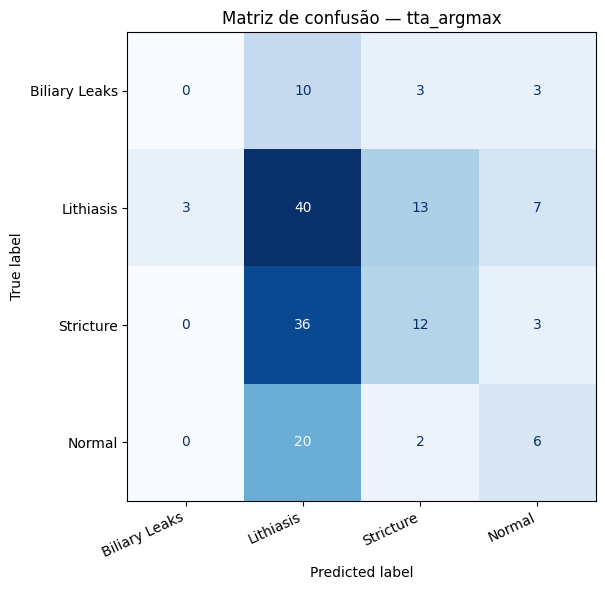

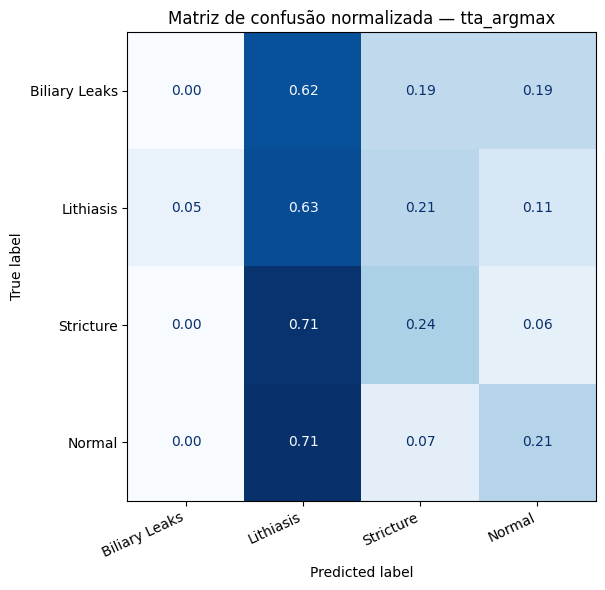

In [56]:
# =========================
# 22. Matriz de confusão
# =========================

cm = confusion_matrix(best_test_metrics["y_true"], best_test_metrics["y_pred"], labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title(f"Matriz de confusão — {best_method_name}")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_best_test.png", dpi=300, bbox_inches="tight")
plt.show()

cm_norm = confusion_matrix(
    best_test_metrics["y_true"],
    best_test_metrics["y_pred"],
    labels=list(range(NUM_CLASSES)),
    normalize="true"
)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
plt.title(f"Matriz de confusão normalizada — {best_method_name}")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_best_test_normalized.png", dpi=300, bbox_inches="tight")
plt.show()

Baseline macro F1: 0.738
Melhor macro F1 teste: 0.2562470565743888
Diferença: -0.4817529434256112


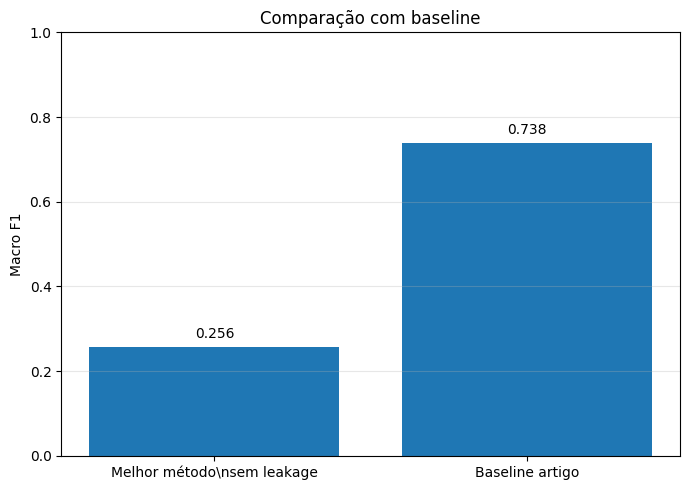

In [57]:
# =========================
# 23. Comparação com baseline
# =========================

best_macro_f1 = best_test_metrics["macro_f1"]
diff = best_macro_f1 - BASELINE_MACRO_F1

print("Baseline macro F1:", BASELINE_MACRO_F1)
print("Melhor macro F1 teste:", best_macro_f1)
print("Diferença:", diff)

plt.figure(figsize=(7, 5))
labels = ["Melhor método\\nsem leakage", "Baseline artigo"]
values = [best_macro_f1, BASELINE_MACRO_F1]
bars = plt.bar(labels, values)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.015, f"{value:.3f}", ha="center", va="bottom")

plt.ylabel("Macro F1")
plt.title("Comparação com baseline")
plt.ylim(0, 1.0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "macro_f1_vs_baseline_best.png", dpi=300, bbox_inches="tight")
plt.show()

In [58]:
# =========================
# 24. Probabilidades por classe
# =========================

probs_df = pd.DataFrame(best_test_metrics["y_prob"], columns=[f"prob_{c}" for c in class_names])
probs_df["true_idx"] = best_test_metrics["y_true"]
probs_df["pred_idx"] = best_test_metrics["y_pred"]
probs_df["true_label"] = [idx_to_class[i] for i in best_test_metrics["y_true"]]
probs_df["pred_label"] = [idx_to_class[i] for i in best_test_metrics["y_pred"]]
probs_df["image_path"] = test_df.reset_index(drop=True)["image_path"].values[:len(probs_df)]

probs_df.to_csv(CSV_DIR / "test_probabilities_best_method.csv", index=False)
display(probs_df.head())

,prob_Biliary Leaks,prob_Lithiasis,prob_Stricture,prob_Normal,true_idx,pred_idx,true_label,pred_label,image_path
0,0.195672,0.252441,0.272848,0.279039,2,3,Stricture,Normal,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...
1,0.198648,0.259260,0.300396,0.241696,2,2,Stricture,Stricture,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...
2,0.166391,0.381433,0.244744,0.207432,1,1,Lithiasis,Lithiasis,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...
3,0.194730,0.290615,0.274068,0.240587,1,1,Lithiasis,Lithiasis,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...
4,0.218806,0.325541,0.286479,0.169174,3,1,Normal,Lithiasis,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...


/mounts/mecd-ap-g5/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,image_type,n,accuracy,balanced_accuracy,macro_f1
0,S,153,0.366013,0.262396,0.24238
1,V,5,0.400000,0.333333,0.20000


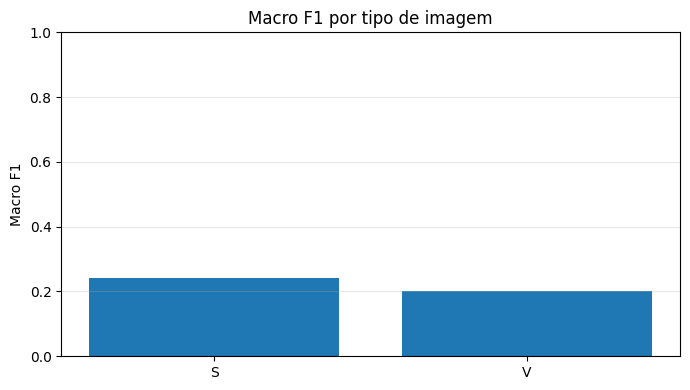

In [59]:
# =========================
# 25. Análise por image_type
# =========================

if "image_type" in test_df.columns:
    type_df = test_df.reset_index(drop=True).copy()
    type_df = type_df.iloc[:len(best_test_metrics["y_true"])].copy()
    type_df["y_true"] = best_test_metrics["y_true"]
    type_df["y_pred"] = best_test_metrics["y_pred"]

    rows = []
    for img_type, g in type_df.groupby("image_type"):
        rows.append({
            "image_type": img_type,
            "n": len(g),
            "accuracy": accuracy_score(g["y_true"], g["y_pred"]),
            "balanced_accuracy": balanced_accuracy_score(g["y_true"], g["y_pred"]),
            "macro_f1": f1_score(g["y_true"], g["y_pred"], average="macro", zero_division=0),
        })

    type_metrics_df = pd.DataFrame(rows)
    display(type_metrics_df)
    type_metrics_df.to_csv(CSV_DIR / "metrics_by_image_type_best_method.csv", index=False)

    plt.figure(figsize=(7, 4))
    plt.bar(type_metrics_df["image_type"], type_metrics_df["macro_f1"])
    plt.ylabel("Macro F1")
    plt.title("Macro F1 por tipo de imagem")
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "macro_f1_by_image_type_best_method.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Coluna image_type não existe.")

In [60]:
# =========================
# 26. Guardar resumo final
# =========================

summary = {
    "split_mode": "StratifiedGroupKFold_patient_id_no_leakage",
    "model": "EfficientNetV2-S",
    "loss": "CrossEntropyLoss_weighted_label_smoothing",
    "threshold_tuning": True,
    "tta": True,
    "baseline_macro_f1": BASELINE_MACRO_F1,
    "best_val_macro_f1": float(best_val_f1),
    "best_test_method": str(best_method_name),
    "test_accuracy": float(best_test_metrics["accuracy"]),
    "test_balanced_accuracy": float(best_test_metrics["balanced_accuracy"]),
    "test_macro_f1": float(best_test_metrics["macro_f1"]),
    "test_weighted_f1": float(best_test_metrics["weighted_f1"]),
    "test_macro_precision": float(best_test_metrics["macro_precision"]),
    "test_macro_recall": float(best_test_metrics["macro_recall"]),
    "test_roc_auc_macro_ovr": float(best_test_metrics.get("roc_auc_macro_ovr", np.nan)),
    "test_pr_auc_macro": float(best_test_metrics.get("pr_auc_macro", np.nan)),
    "difference_to_baseline": float(best_test_metrics["macro_f1"] - BASELINE_MACRO_F1),
    "train_patients": int(train_df["patient_id"].nunique()),
    "val_patients": int(val_df["patient_id"].nunique()),
    "test_patients": int(test_df["patient_id"].nunique()),
    "leak_train_val": int(leak_train_val),
    "leak_train_test": int(leak_train_test),
    "leak_val_test": int(leak_val_test),
}

with open(RESULTS_DIR / "final_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=4, ensure_ascii=False)

pd.DataFrame([summary]).to_csv(CSV_DIR / "final_summary.csv", index=False)
summary

{'split_mode': 'StratifiedGroupKFold_patient_id_no_leakage',
 'model': 'EfficientNetV2-S',
 'loss': 'CrossEntropyLoss_weighted_label_smoothing',
 'threshold_tuning': True,
 'tta': True,
 'baseline_macro_f1': 0.738,
 'best_val_macro_f1': 0.2986573402486603,
 'best_test_method': 'tta_argmax',
 'test_accuracy': 0.3670886075949367,
 'test_balanced_accuracy': 0.271125116713352,
 'test_macro_f1': 0.2562470565743888,
 'test_weighted_f1': 0.32963628157230673,
 'test_macro_precision': 0.27328699106256205,
 'test_macro_recall': 0.271125116713352,
 'test_roc_auc_macro_ovr': 0.5176220694808326,
 'test_pr_auc_macro': 0.28347962177322356,
 'difference_to_baseline': -0.4817529434256112,
 'train_patients': 346,
 'val_patients': 45,
 'test_patients': 45,
 'leak_train_val': 0,
 'leak_train_test': 0,
 'leak_val_test': 0}

In [61]:
# =========================
# 27. Grad-CAM
# =========================

def replace_inplace_relu(module):
    for name, child in module.named_children():
        if isinstance(child, nn.ReLU):
            setattr(module, name, nn.ReLU(inplace=False))
        else:
            replace_inplace_relu(child)

replace_inplace_relu(model)

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_handle = self.target_layer.register_forward_hook(self.save_activation)
        self.backward_handle = self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach().clone()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach().clone()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)

        logits = self.model(x)

        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        score = logits[:, class_idx].sum()
        score.backward(retain_graph=False)

        gradients = self.gradients
        activations = self.activations

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1)
        cam = F.relu(cam)

        cam = F.interpolate(cam.unsqueeze(1), size=x.shape[2:], mode="bilinear", align_corners=False).squeeze(1)
        cam = cam[0].detach().cpu().numpy()
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam, logits.detach()

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

target_layer = model.features[-1]
gradcam = GradCAM(model, target_layer)
print("Grad-CAM preparado.")

Grad-CAM preparado.


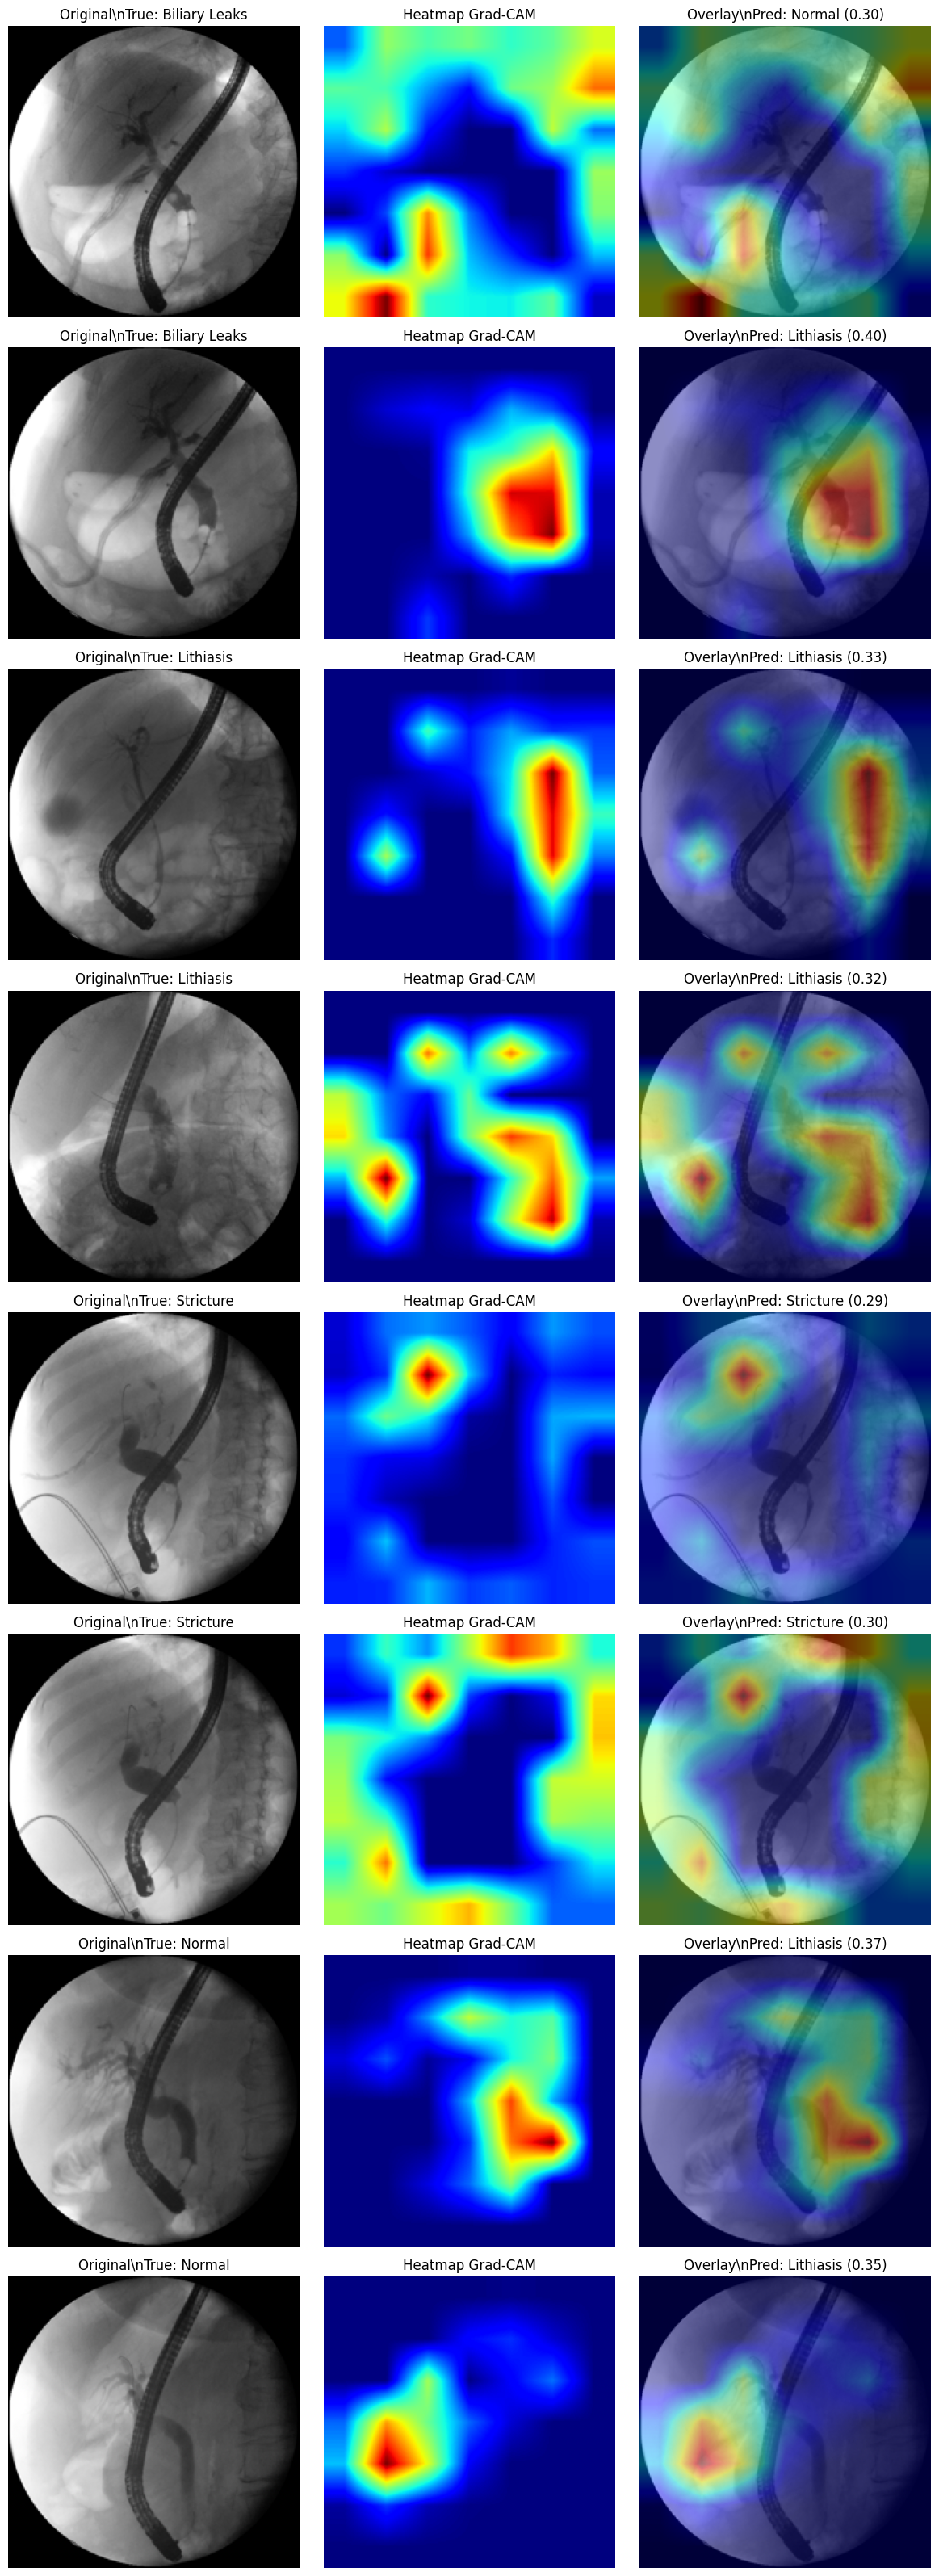

Grad-CAM guardado em: /mounts/mecd-ap-g5/results/efficientnetv2s_no_leakage_threshold_tuning/figures/gradcam_examples_by_class.png


In [62]:
# =========================
# 28. Exemplos Grad-CAM por classe
# =========================

def load_original_image_for_display(path):
    img = Image.open(path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    return np.array(img) / 255.0

def show_gradcam_examples(model, dataset, dataframe, n_per_class=2):
    model.eval()

    selected_indices = []
    df_reset = dataframe.reset_index(drop=True)

    for class_idx in range(NUM_CLASSES):
        class_indices = df_reset.index[df_reset["label_idx"] == class_idx].tolist()
        selected_indices.extend(class_indices[:n_per_class])

    n = len(selected_indices)
    if n == 0:
        print("Sem exemplos.")
        return

    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_i, idx in enumerate(selected_indices):
        img_tensor, true_label = dataset[idx]
        x = img_tensor.unsqueeze(0).to(device)

        cam, logits = gradcam(x)
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()[0]
        pred_label = int(np.argmax(probs))

        original = load_original_image_for_display(df_reset.iloc[idx]["image_path"])

        axes[row_i, 0].imshow(original)
        axes[row_i, 0].set_title(f"Original\\nTrue: {class_names[true_label]}")
        axes[row_i, 0].axis("off")

        axes[row_i, 1].imshow(cam, cmap="jet")
        axes[row_i, 1].set_title("Heatmap Grad-CAM")
        axes[row_i, 1].axis("off")

        axes[row_i, 2].imshow(original)
        axes[row_i, 2].imshow(cam, cmap="jet", alpha=0.45)
        axes[row_i, 2].set_title(f"Overlay\\nPred: {class_names[pred_label]} ({probs[pred_label]:.2f})")
        axes[row_i, 2].axis("off")

    plt.tight_layout()
    out_path = FIGURES_DIR / "gradcam_examples_by_class.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Grad-CAM guardado em:", out_path)

show_gradcam_examples(model, test_dataset, test_df, n_per_class=2)
gradcam.close()
clean_cuda()

In [63]:
# =========================
# 29. Guardar configuração final
# =========================

config = {
    "DATA_ROOT": str(DATA_ROOT),
    "DATASET_DIR": str(DATASET_DIR),
    "PROCESSED_IMAGES_DIR": str(PROCESSED_IMAGES_DIR),
    "METADATA_PATH": str(METADATA_PATH),
    "NOTEBOOK_NAME": NOTEBOOK_NAME,
    "IMG_SIZE": IMG_SIZE,
    "BATCH_SIZE": BATCH_SIZE,
    "ACCUMULATION_STEPS": ACCUMULATION_STEPS,
    "NUM_WORKERS": NUM_WORKERS,
    "EPOCHS_HEAD": EPOCHS_HEAD,
    "EPOCHS_FINETUNE": EPOCHS_FINETUNE,
    "PATIENCE": PATIENCE,
    "LR_HEAD": LR_HEAD,
    "LR_BACKBONE": LR_BACKBONE,
    "WEIGHT_DECAY": WEIGHT_DECAY,
    "LABEL_SMOOTHING": LABEL_SMOOTHING,
    "BASELINE_MACRO_F1": BASELINE_MACRO_F1,
    "CLASS_NAMES": class_names,
    "SPLIT_MODE": "StratifiedGroupKFold_by_patient_id",
    "NO_LEAKAGE": True,
    "MODEL": "EfficientNetV2-S",
    "LOSS": "CrossEntropyLoss_weighted_label_smoothing",
    "THRESHOLD_TUNING": True,
    "TTA": True,
}

with open(RESULTS_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=4, ensure_ascii=False)

print("Ficheiros guardados em:")
print("Results:", RESULTS_DIR)
print("Models:", MODELS_DIR)
print("Figures:", FIGURES_DIR)
print("CSV:", CSV_DIR)

Ficheiros guardados em:
Results: /mounts/mecd-ap-g5/results/efficientnetv2s_no_leakage_threshold_tuning
Models: /mounts/mecd-ap-g5/models/efficientnetv2s_no_leakage_threshold_tuning
Figures: /mounts/mecd-ap-g5/results/efficientnetv2s_no_leakage_threshold_tuning/figures
CSV: /mounts/mecd-ap-g5/results/efficientnetv2s_no_leakage_threshold_tuning/csv
